# Brain Tumor Detection & Classification — CNN (EfficientNet-B0) + GAT

This notebook implements a hybrid **CNN + Graph Attention Network (GAT)** model for brain MRI
classification, as specified in the project brief:

- **CNN backbone**: EfficientNet-B0 (pretrained on ImageNet) extracts spatial features.
- **Graph construction**: the feature map is divided into a 7x7 grid (49 patches). Each patch
  becomes a graph node, with edges connecting spatially adjacent patches (4-connectivity).
- **GNN head**: a 3-layer Graph Attention Network (GAT) reasons over the patch graph and
  produces the final classification.
- **Explainability**: Grad-CAM highlights the image regions that most influenced the prediction.
- **Metrics**: accuracy, precision, recall, F1-score (per-class and macro/weighted), and a
  confusion matrix.

## A note on "tumor stage" classification

Public brain-MRI datasets (e.g. the Kaggle *Brain Tumor MRI Dataset*) are labeled by **tumor
type** — `glioma`, `meningioma`, `pituitary`, `notumor` — not by clinical stage (Stage I-IV).
Clinical staging requires expert radiological/pathological annotations that are not present in
these public datasets.

This notebook therefore classifies **tumor presence and tumor type**, which is what the data
supports, and is the standard formulation used in the literature. If you obtain a dataset with
stage labels (e.g. a subset of BraTS with clinical metadata), the code is generic: simply point
`DATA_ROOT` at a folder structured as `Training/<class>/...` and `Testing/<class>/...` where
`<class>` are your stage labels, and update `CLASS_NAMES` to match — no other changes are needed.

## Expected dataset layout

```
DATA_ROOT/
    Training/
        glioma/  meningioma/  notumor/  pituitary/
    Testing/
        glioma/  meningioma/  notumor/  pituitary/
```


## 0. (Optional) Google Colab setup

Skip this cell if you are running locally / already have the dependencies installed.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# !pip install -q timm torch-geometric


## 1. Imports & Reproducibility

In [24]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, global_mean_pool
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, accuracy_score)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 4
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 3e-4
IMG_SIZE    = 224
NODE_DIM    = 128
GNN_HIDDEN  = 256
GAT_HEADS   = 4
DROPOUT     = 0.4

CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

print(f"Device: {DEVICE}")


Device: cpu


## 2. Data Loading, Preprocessing & Augmentation

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(split: str):
    """Image normalization, resizing, and augmentation for train/val splits."""
    if split == "train":
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.3, contrast=0.3,
                                   saturation=0.2, hue=0.05),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1),
                                    scale=(0.9, 1.1)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def load_datasets(root: str):
    """
    Expects folder layout:
        root/
          Training/  glioma/ meningioma/ notumor/ pituitary/
          Testing/   glioma/ meningioma/ notumor/ pituitary/
    """
    train_ds = datasets.ImageFolder(os.path.join(root, "Training"),
                                    transform=get_transforms("train"))
    val_ds   = datasets.ImageFolder(os.path.join(root, "Testing"),
                                    transform=get_transforms("val"))

    # Weighted sampler to handle class imbalance
    labels      = [s[1] for s in train_ds.samples]
    class_count = np.bincount(labels)
    weights     = 1.0 / class_count[labels]
    sampler     = WeightedRandomSampler(weights, len(weights))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=2,
                              pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2,
                              pin_memory=True)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
    print(f"Classes: {train_ds.classes}")
    return train_loader, val_loader


## 3. CNN Backbone — EfficientNet-B0

EfficientNet-B0 is used as the CNN feature extractor (lighter and faster than B3/ResNet50,
recommended for an M.Sc.-scale project while still giving strong accuracy). The output channel
count is detected dynamically with a dummy forward pass, so this class also works unchanged
if you swap in `resnet50`, `efficientnet_b3`, etc.

In [4]:
class CNNBackbone(nn.Module):
    """
    EfficientNet-B0 with the classifier head removed.
    Returns a spatial feature map: (B, C, H', W')
    """
    def __init__(self, model_name: str = "efficientnet_b0",
                 freeze_until_layer: int = 5, pretrained: bool = True):
        super().__init__()
        base = timm.create_model(model_name, pretrained=pretrained,
                                 features_only=True)
        self.features = nn.Sequential(*list(base.children())[:freeze_until_layer])

        # Freeze the earliest layers for stable fine-tuning
        for i, child in enumerate(self.features.children()):
            if i < 3:
                for p in child.parameters():
                    p.requires_grad = False

        # Determine output channel count dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            out = self.features(dummy)
            if isinstance(out, (list, tuple)):
                out = out[-1]
            self.out_channels = out.shape[1]

    def forward(self, x):
        out = self.features(x)
        if isinstance(out, (list, tuple)):
            out = out[-1]
        return out                       # (B, C, H', W')


## 4. Graph Construction

The CNN feature map is pooled to a 7x7 grid (49 patches). Each patch becomes a graph node, with edges connecting spatially adjacent patches (4-connectivity).

In [5]:
class GraphBuilder(nn.Module):
    """
    Converts CNN feature map patches into graph nodes.
    Each patch -> one node; edges connect spatially adjacent patches.
    Node feature dimension is projected to `node_dim`.
    """
    def __init__(self, in_channels: int, node_dim: int = NODE_DIM):
        super().__init__()
        self.proj = nn.Sequential(
            nn.AdaptiveAvgPool2d((7, 7)),   # fixed 7x7 = 49 patches
            nn.Flatten(start_dim=2),        # keep batch & channel dims
        )
        self.node_embed = nn.Linear(in_channels, node_dim)
        self._build_static_edges()

    # Pre-compute 4-connectivity edges on a 7x7 grid (same for every image)
    def _build_static_edges(self):
        G = 7
        src, dst = [], []
        for r in range(G):
            for c in range(G):
                n = r * G + c
                if c + 1 < G: src += [n, n + 1];     dst += [n + 1, n]
                if r + 1 < G: src += [n, n + G];     dst += [n + G, n]
        self.register_buffer("edge_index",
                             torch.tensor([src, dst], dtype=torch.long))

    def forward(self, feat_map):
        """
        feat_map: (B, C, H, W)
        Returns list of torch_geometric.data.Data objects (one per sample)
        """
        B, C, _, _ = feat_map.shape
        x = self.proj(feat_map).permute(0, 2, 1)   # (B, 49, C)
        x = self.node_embed(x)                     # (B, 49, node_dim)

        graphs = []
        for i in range(B):
            graphs.append(Data(x=x[i], edge_index=self.edge_index.clone()))
        return graphs


## 5. GNN Head — 3-layer Graph Attention Network (GAT)

A GAT is used instead of a plain GCN so that each patch can learn *attention weights* over its
neighbours — letting the model focus more on patches that are most informative for the
diagnosis.

In [6]:
class GNNHead(nn.Module):
    """
    3-layer Graph Attention Network (GAT).
    Global mean pooling -> per-graph embedding -> classifier.
    """
    def __init__(self, node_dim: int = NODE_DIM, hidden: int = GNN_HIDDEN,
                 num_classes: int = NUM_CLASSES, dropout: float = DROPOUT,
                 heads: int = GAT_HEADS):
        super().__init__()
        self.conv1 = GATConv(node_dim, hidden, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden, heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden * heads, hidden // 2, heads=1,
                              concat=False, dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.cls = nn.Sequential(
            nn.Linear(hidden // 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = F.elu(self.conv1(x, ei)); x = self.drop(x)
        x = F.elu(self.conv2(x, ei)); x = self.drop(x)
        x = F.elu(self.conv3(x, ei))
        x = global_mean_pool(x, batch)        # (B, hidden//2)
        return self.cls(x)


## 6. Full Hybrid Model (CNN + GAT)

In [7]:
class BrainTumorDetector(nn.Module):
    def __init__(self, cnn_name: str = "efficientnet_b0",
                 node_dim: int = NODE_DIM, gnn_hidden: int = GNN_HIDDEN,
                 dropout: float = DROPOUT, pretrained: bool = True):
        super().__init__()
        self.cnn   = CNNBackbone(cnn_name, pretrained=pretrained)
        self.graph = GraphBuilder(self.cnn.out_channels, node_dim)
        self.gnn   = GNNHead(node_dim, gnn_hidden, NUM_CLASSES, dropout)

    def forward(self, images):
        feat_map = self.cnn(images)              # (B, C, H, W)
        graphs   = self.graph(feat_map)
        batch    = Batch.from_data_list(graphs).to(images.device)
        return self.gnn(batch)


model = BrainTumorDetector().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Total parameters:     4,970,752
Trainable parameters: 1,375,364


## 7. Training Utilities

In [8]:
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing: float = 0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n   = logits.size(1)
        log = F.log_softmax(logits, dim=1)
        smooth_loss = -log.mean(dim=1)
        nll_loss    = F.nll_loss(log, targets, reduction="none")
        return ((1 - self.smoothing) * nll_loss
                + self.smoothing * smooth_loss).mean()


def build_optimizer_scheduler(model, epochs: int):
    # Differential learning rates: backbone gets 10x smaller LR
    backbone_params = list(model.cnn.parameters())
    head_params     = list(model.graph.parameters()) + \
                      list(model.gnn.parameters())

    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": LR / 10},
        {"params": head_params,     "lr": LR},
    ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6)

    return optimizer, scheduler


## 8. Train / Evaluate Loops

In [9]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc="Val  ", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds  .extend(preds.cpu().numpy())
        all_labels .extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels


## 9. Metrics — Accuracy, Precision, Recall, F1, Confusion Matrix

In [10]:
def print_metrics(y_true, y_pred, class_names=CLASS_NAMES):
    """Print accuracy, per-class precision/recall/F1, and macro/weighted averages."""
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0)

    print(f"Overall Accuracy: {acc:.4f}\n")
    print(f"{'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-score':>10} {'Support':>10}")
    for i, name in enumerate(class_names):
        print(f"{name:<12} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>10.4f} {support[i]:>10d}")

    print("\nFull classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return acc, precision, recall, f1


def plot_confusion(y_true, y_pred, class_names=CLASS_NAMES, save_path="confusion_matrix.png"):
    cm_arr = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm_arr, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved confusion matrix -> {save_path}")


## 10. Training-History Plots (Loss & Accuracy)

In [11]:
def plot_history(history, save_path="training_history.png"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_range = range(1, len(history["train_acc"]) + 1)

    axes[0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0].plot(epochs_range, history["val_loss"],   label="Val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Training vs Validation Loss"); axes[0].legend()

    axes[1].plot(epochs_range, history["train_acc"], label="Train")
    axes[1].plot(epochs_range, history["val_acc"],   label="Val")
    axes[1].axhline(0.9, color="red", linestyle="--", label="90% target")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training vs Validation Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved training plot -> {save_path}")


## 11. Grad-CAM Explainability

Grad-CAM is hooked onto the last layer of the CNN backbone (the feature map that feeds the
graph builder). It produces a heatmap showing which image regions most influenced the model's
prediction — useful for highlighting the tumor region.

In [22]:
# =====================================================
# Grad-CAM for CNN + GNN Brain Tumor Detector
# =====================================================

class GradCAM:

    def __init__(self, model):

        self.model = model
        self.gradients = None
        self.activations = None

        target_layer = model.cnn.features[-1]

        target_layer.register_forward_hook(
            self._save_activation
        )

        target_layer.register_full_backward_hook(
            self._save_gradient
        )

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, input_tensor, class_idx=None):

        self.model.eval()

        logits = self.model(input_tensor)

        probs = F.softmax(logits, dim=1)[0]

        if class_idx is None:
            class_idx = int(torch.argmax(probs).item())

        self.model.zero_grad(set_to_none=True)

        score = logits[0, class_idx]

        score.backward(retain_graph=True)

        print("Activations:", self.activations)
        print("Gradients:", self.gradients)

        if self.activations is None:
            print("Activations not captured!")
            return None, None, None

        if self.gradients is None:
            print("Gradients not captured!")
            return None, None, None

        activations = self.activations[0]
        gradients = self.gradients[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(
            activations.shape[1:],
            device=activations.device
        )

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)

        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return (
            cam.cpu().numpy(),
            class_idx,
            probs.detach().cpu().numpy()
        )


# =====================================================
# Show Grad-CAM
# =====================================================

def show_gradcam(model, image_path, class_idx=None, alpha=0.45):

    transform = get_transforms("val")

    img = Image.open(image_path).convert("RGB")

    x = transform(img).unsqueeze(0).to(DEVICE)

    gradcam = GradCAM(model)

    cam, pred_idx, probs = gradcam(
        x,
        class_idx=class_idx
    )

    if cam is None:
        print("Grad-CAM generation failed.")
        return

    cam_resized = np.array(
        Image.fromarray(
            (cam * 255).astype(np.uint8)
        ).resize(img.size)
    )

    heatmap = cm.jet(
        cam_resized / 255.0
    )[..., :3]

    img_np = np.array(
        img.resize((IMG_SIZE, IMG_SIZE))
    ) / 255.0

    heatmap_resized = np.array(
        Image.fromarray(
            (heatmap * 255).astype(np.uint8)
        ).resize((IMG_SIZE, IMG_SIZE))
    ) / 255.0

    overlay = (
        (1 - alpha) * img_np
        + alpha * heatmap_resized
    )

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(
        cam_resized,
        cmap="jet"
    )
    axes[1].set_title("Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(
        f"{CLASS_NAMES[pred_idx]} "
        f"({probs[pred_idx] * 100:.2f}%)"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return pred_idx, probs

## 12. Main Training Function

In [13]:
def train(data_root: str, save_path: str = "models/best_model.pth"):
    train_loader, val_loader = load_datasets(data_root)
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)

    model     = BrainTumorDetector().to(DEVICE)
    criterion = LabelSmoothingCE(smoothing=0.1)
    optimizer, scheduler = build_optimizer_scheduler(model, EPOCHS)
    scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history  = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0
    best_preds, best_labels = None, None

    print(f"\n{'='*60}")
    print(f"  Brain Tumor Detector  |  CNN (EfficientNet-B0) + GAT  |  {DEVICE}")
    print(f"{'='*60}\n")

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        vl_loss, vl_acc, preds, labels = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)

        flag = " *" if vl_acc > best_acc else ""
        print(f"Epoch {epoch:02d}/{EPOCHS}  "
              f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
              f"vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.4f}{flag}")

        if vl_acc > best_acc:
            best_acc = vl_acc
            best_preds, best_labels = preds, labels
            torch.save({"epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "val_acc": best_acc,
                        "class_names": CLASS_NAMES}, save_path)

    print(f"\nBest validation accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
    print(f"Checkpoint saved to: {save_path}")

    plot_history(history)
    print_metrics(best_labels, best_preds)
    plot_confusion(best_labels, best_preds)
    return model, history, best_acc


## 13. Run Training

Set `DATA_ROOT` to your dataset folder (must contain `Training/` and `Testing/` subfolders,
each with `glioma/`, `meningioma/`, `notumor/`, `pituitary/`). The checkpoint used by the
Flask app will be saved to `models/best_model.pth` (copy the project folder structure, or
adjust `SAVE_PATH` to match your deployment folder).

Train: 5600 | Val: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
C:\Users\lokes\AppData\Local\Temp\ipykernel_24640\3963740532.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))



  Brain Tumor Detector  |  CNN (EfficientNet-B0) + GAT  |  cpu



Train:   0%|          | 0/175 [00:00<?, ?it/s]c:\Users\lokes\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\lokes\AppData\Local\Temp\ipykernel_24640\2348451468.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):


Epoch 01/15  tr_loss=0.7614  tr_acc=0.8046  vl_loss=0.8296  vl_acc=0.7744 *


...

Epoch 11/15  tr_loss=0.5480  tr_acc=0.9052  vl_loss=0.7032  vl_acc=0.8506


Epoch 12/15  tr_loss=0.5333  tr_acc=0.9127  vl_loss=0.6833  vl_acc=0.8556


Epoch 13/15  tr_loss=0.5394  tr_acc=0.9100  vl_loss=0.6978  vl_acc=0.8506


Epoch 14/15  tr_loss=0.5262  tr_acc=0.9166  vl_loss=0.6966  vl_acc=0.8556


Epoch 15/15  tr_loss=0.5236  tr_acc=0.9179  vl_loss=0.7049  vl_acc=0.8506

Best validation accuracy: 0.8644 (86.44%)
Checkpoint saved to: models/best_model.pth


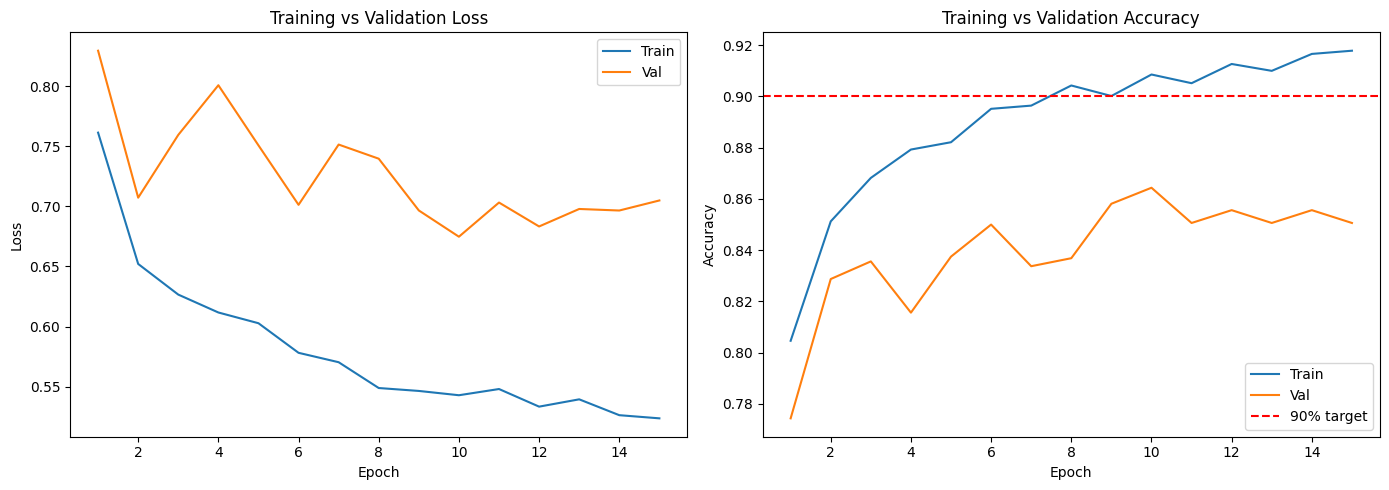

Saved training plot -> training_history.png
Overall Accuracy: 0.8644

Class         Precision     Recall   F1-score    Support
glioma           0.9485     0.6900     0.7988        400
meningioma       0.7995     0.8175     0.8084        400
notumor          0.8458     0.9875     0.9112        400
pituitary        0.8891     0.9625     0.9244        400

Full classification report:
              precision    recall  f1-score   support

      glioma       0.95      0.69      0.80       400
  meningioma       0.80      0.82      0.81       400
     notumor       0.85      0.99      0.91       400
   pituitary       0.89      0.96      0.92       400

    accuracy                           0.86      1600
   macro avg       0.87      0.86      0.86      1600
weighted avg       0.87      0.86      0.86      1600



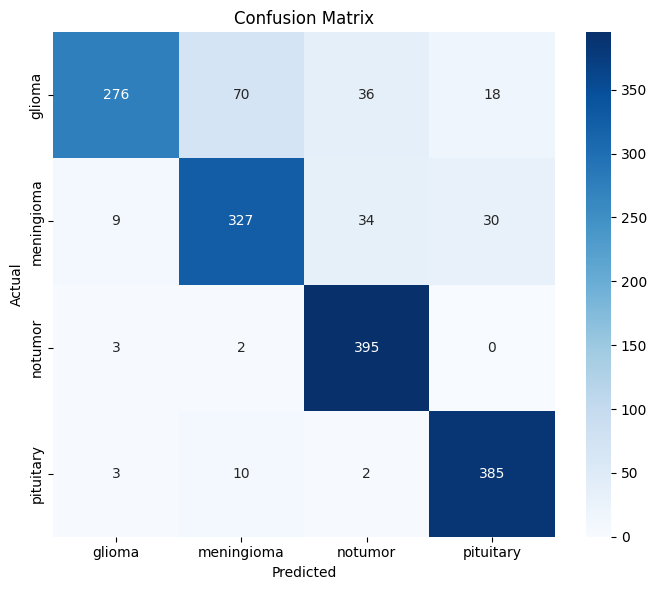

Saved confusion matrix -> confusion_matrix.png


In [25]:
DATA_ROOT = r"D:\\SBP PROJECT"          # folder containing Training/ and Testing/
SAVE_PATH = "models/best_model.pth"   # used by app.py

model, history, best_acc = train(DATA_ROOT, SAVE_PATH)


## 14. Inference on a Single Image

In [15]:
def predict(image_path: str, checkpoint: str = SAVE_PATH):
    transform = get_transforms("val")
    img = Image.open(image_path).convert("RGB")
    x   = transform(img).unsqueeze(0).to(DEVICE)

    model = BrainTumorDetector(pretrained=False).to(DEVICE)
    ckpt  = torch.load(checkpoint, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    with torch.no_grad():
        logits = model(x)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
        pred   = int(probs.argmax())

    print(f"\nPrediction: {CLASS_NAMES[pred]}")
    for c, p in zip(CLASS_NAMES, probs):
        bar = "#" * int(p * 40)
        print(f"  {c:12s} {p*100:5.1f}%  {bar}")
    return CLASS_NAMES[pred], probs, model


## 15. Run Inference + Grad-CAM on a Test Image

In [26]:
IMAGE_PATH = r"E:\SBP/Training/meningioma/Tr-aug-me_3.jpg"

pred_class, probabilities, loaded_model = predict(
    IMAGE_PATH,
    SAVE_PATH
)

show_gradcam(loaded_model, IMAGE_PATH)



Prediction: meningioma
  glioma         7.5%  ###
  meningioma    81.6%  ################################
  notumor        4.4%  #
  pituitary      6.5%  ##
Activations: tensor([[[[ 2.2975, -0.0375, -1.2589,  ...,  0.0373, -0.0546, -0.0385],
          [-0.8505, -1.1927, -1.3857,  ...,  1.8686,  1.3239, -0.7451],
          [-1.6396, -1.4348,  1.0305,  ...,  3.6229,  3.4854, -0.2953],
          ...,
          [ 0.4921,  0.7465,  3.7092,  ...,  0.9893, -0.7122, -0.7692],
          [ 0.6825,  0.7705,  0.4572,  ..., -0.5987, -0.9109, -1.3239],
          [ 0.4710, -0.5732, -1.6663,  ..., -3.2921, -2.0378, -2.0295]],

         [[ 3.2369,  2.8221,  2.6091,  ...,  1.8733,  1.4586,  1.9651],
          [ 2.5055,  2.9869, -0.0548,  ..., -0.4095,  2.3096,  1.6970],
          [ 1.5767,  0.3902, -4.1651,  ..., -3.2425,  0.7886,  1.7444],
          ...,
          [-0.1786, -4.2372, -1.9696,  ..., -0.8301,  0.6582, -0.2112],
          [ 0.5248,  0.1976,  0.7998,  ...,  1.6964,  0.8961,  0.0556],
     

## 16. Export for the Flask App

Copy (or symlink) the saved checkpoint into the Flask project's `models/` directory so
`app.py` can load it:

```
brain_tumor_project/
    models/
        best_model.pth      <- copy SAVE_PATH here
    app.py
    model.py
    templates/
    static/
```

The `model.py` module in the Flask project contains the same `BrainTumorDetector`,
`GraphBuilder`, `GNNHead`, `CNNBackbone`, `GradCAM`, and `get_transforms` definitions used
above, so the checkpoint loads with no changes.